In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Clustering
from sklearn.cluster import KMeans

# NLP (for column analysis / feature interpretation)
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("Diabetes Missing Data.csv")

print(df.head())
print(df.info())

   Pregnant  Glucose  Diastolic_BP  ...  Diabetes_Pedigree  Age  Class
0         6    148.0          72.0  ...              0.627   50      1
1         1     85.0          66.0  ...              0.351   31      0
2         8    183.0          64.0  ...              0.672   32      1
3         1     89.0          66.0  ...              0.167   21      0
4         0    137.0          40.0  ...              2.288   33      1

[5 rows x 9 columns]
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pregnant           768 non-null    int64  
 1   Glucose            763 non-null    float64
 2   Diastolic_BP       733 non-null    float64
 3   Skin_Fold          541 non-null    float64
 4   Serum_Insulin      394 non-null    float64
 5   BMI                757 non-null    float64
 6   Diabetes_Pedigree  768 non-null    float64
 7   Age                768

Pregnant               0
Glucose                5
Diastolic_BP          35
Skin_Fold            227
Serum_Insulin        374
BMI                   11
Diabetes_Pedigree      0
Age                    0
Class                  0
dtype: int64


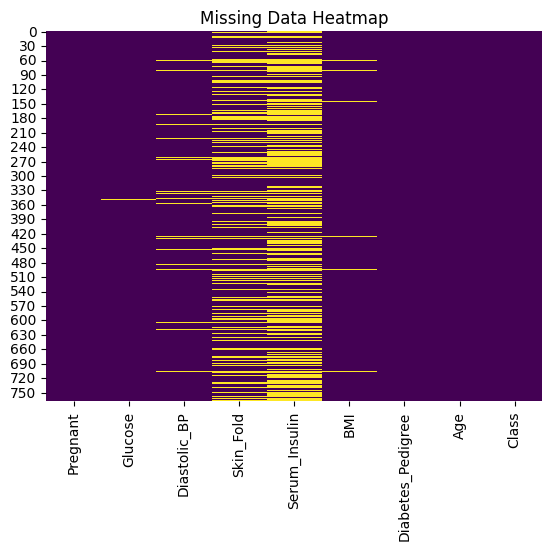

In [3]:
missing = df.isnull().sum()
print(missing)

# Visualize missing data
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [4]:
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print(df_imputed.isnull().sum())

Pregnant             0
Glucose              0
Diastolic_BP         0
Skin_Fold            0
Serum_Insulin        0
BMI                  0
Diabetes_Pedigree    0
Age                  0
Class                0
dtype: int64


In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_imputed)

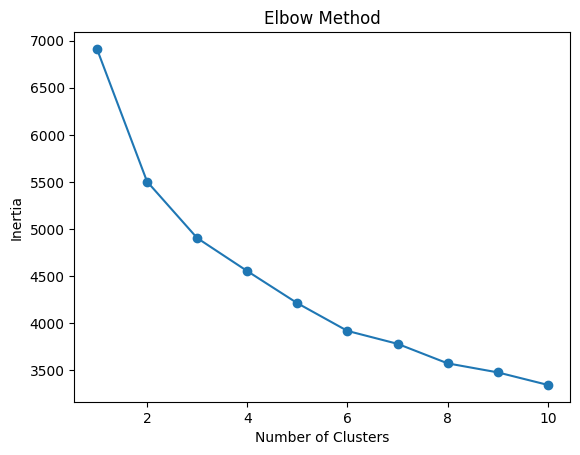

In [6]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df_imputed['Cluster'] = clusters

print(df_imputed.head())

   Pregnant  Glucose  Diastolic_BP  ...   Age  Class  Cluster
0       6.0    148.0          72.0  ...  50.0    1.0        2
1       1.0     85.0          66.0  ...  31.0    0.0        1
2       8.0    183.0          64.0  ...  32.0    1.0        2
3       1.0     89.0          66.0  ...  21.0    0.0        1
4       0.0    137.0          40.0  ...  33.0    1.0        0

[5 rows x 10 columns]


In [8]:
cluster_summary = df_imputed.groupby('Cluster').mean()
print(cluster_summary)

         Pregnant     Glucose  ...        Age     Class
Cluster                        ...                     
0        2.058442  145.212252  ...  30.298701  0.746753
1        2.290667  105.538827  ...  26.456000  0.048000
2        7.435146  131.864798  ...  45.782427  0.564854

[3 rows x 9 columns]


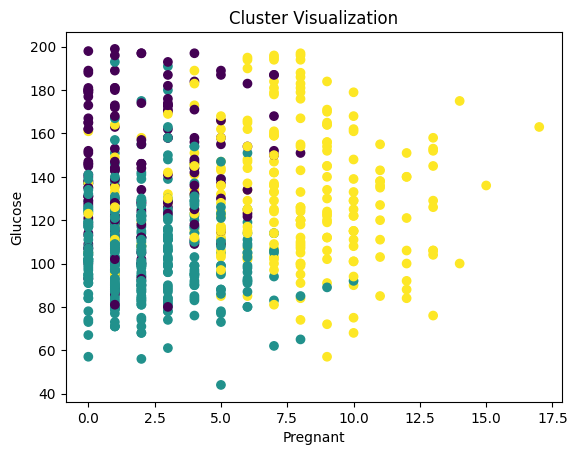

In [9]:
plt.scatter(df_imputed.iloc[:, 0], df_imputed.iloc[:, 1], c=clusters, cmap='viridis')
plt.title("Cluster Visualization")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

In [11]:
text_data = df.columns.astype(str)

In [12]:
cluster_descriptions = []

for i in range(3):
    cluster_data = df_imputed[df_imputed['Cluster'] == i]
    description = cluster_data.mean().sort_values(ascending=False)
    cluster_descriptions.append(description)

for i, desc in enumerate(cluster_descriptions):
    print(f"\nCluster {i} Top Features:\n", desc.head())


Cluster 0 Top Features:
 Serum_Insulin    213.084778
Glucose          145.212252
Diastolic_BP      75.380822
BMI               39.198052
Skin_Fold         36.291620
dtype: float64

Cluster 1 Top Features:
 Serum_Insulin    128.158037
Glucose          105.538827
Diastolic_BP      67.639702
BMI               29.608426
Age               26.456000
dtype: float64

Cluster 2 Top Features:
 Serum_Insulin    161.450693
Glucose          131.864798
Diastolic_BP      77.965049
Age               45.782427
BMI               32.584403
dtype: float64
